In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

import os
import joblib


# Create models directory if it doesn't exist
os.makedirs("models", exist_ok=True)

# Define file paths
log_model_path = "models/logistic_model.pkl"
rf_model_path = "models/random_forest_model.pkl"
xgb_model_path = "models/xgboost_model.pkl"

### Load Scaled Dataset and Train/Test Split

Load the preprocessed dataset, exclude ID columns, and split for modeling.


In [ ]:
df = pd.read_csv("Data/airline_delay_preprocessed_scaled.csv")

# Define training features and target
X = df.drop(columns=[
    'is_delayed',        # target
    'carrier', 'airport',# ID inputs
    'delay_rate',        # leaks label
    'cancel_rate',        # Leaks label
    'year'               #  to avoid tying things to years like 2020 with Covid
])
y = df['is_delayed']

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [3]:
df_corr = df.corr(numeric_only=True)
df_corr['is_delayed'].sort_values(ascending=False)

is_delayed                    1.000000
delay_rate                    0.717926
carrier_airport_delay_rate    0.368975
carrier_delay_rate_overall    0.250651
late_aircraft_delay_pct       0.243617
late_aircraft_ct_rate         0.234294
late_aircraft_delay_rate      0.218952
month_delay_rate              0.218469
airport_delay_rate            0.190907
nas_delay_rate                0.126067
nas_ct_rate                   0.088111
airport_month_volume          0.074116
arr_diverted                  0.072939
nas_delay_pct                 0.061042
arr_flights                   0.034623
carrier_airport_volume        0.010496
security_delay_rate           0.000757
weather_delay_pct            -0.002107
carrier_delay_rate           -0.002568
security_ct_rate             -0.003321
security_delay_pct           -0.006676
weather_delay_rate           -0.010205
weather_ct_rate              -0.016001
month                        -0.027061
cancel_rate                  -0.039761
year                     

### Logistic Regression: Baseline + Hyperparameter Tuning


In [4]:
if os.path.exists(log_model_path):
    print("Loading saved Logistic Regression model...")
    rf_best = joblib.load(log_model_path)

else:
    log_params = {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs']
    }

    log_grid = GridSearchCV(
        LogisticRegression(max_iter=1000),
        log_params,
        scoring='f1',
        cv=3,
        verbose=1
    )

    log_grid.fit(X_train, y_train)
    log_best = log_grid.best_estimator_
    joblib.dump(log_best, log_model_path)
    y_pred_log = log_best.predict(X_test)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


In [5]:
print("Best Parameters:", log_grid.best_params_)
print(classification_report(y_test, y_pred_log))


Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
              precision    recall  f1-score   support

           0       0.72      0.58      0.64     14238
           1       0.74      0.84      0.78     20048

    accuracy                           0.73     34286
   macro avg       0.73      0.71      0.71     34286
weighted avg       0.73      0.73      0.72     34286



### Random Forest Classifier: Grid Search


In [6]:
if os.path.exists(rf_model_path):
    print("Loading saved Random Forest model...")
    rf_best = joblib.load(rf_model_path)
else:
    rf_params = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    }

    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_params,
        scoring='f1',
        cv=3,
        verbose=1,
    )

    rf_grid.fit(X_train, y_train)
    rf_best = rf_grid.best_estimator_
    joblib.dump(rf_best, rf_model_path)
    y_pred_rf = rf_best.predict(X_test)


Fitting 3 folds for each of 12 candidates, totalling 36 fits


### Random Forest Results


In [7]:
print("Best Parameters:", rf_grid.best_params_)
print(classification_report(y_test, y_pred_rf))


Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.80      0.68      0.74     14238
           1       0.80      0.88      0.84     20048

    accuracy                           0.80     34286
   macro avg       0.80      0.78      0.79     34286
weighted avg       0.80      0.80      0.80     34286



### XGBoost Classifier: Grid Search


In [8]:
if os.path.exists(xgb_model_path):
    print("Loading saved XGBoost model...")
    rf_best = joblib.load(xgb_model_path)

else:
    xgb_params = {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1]
    }

    xgb_grid = GridSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
        xgb_params,
        scoring='f1',
        cv=3,
        verbose=1
    )

    xgb_grid.fit(X_train, y_train)
    xgb_best = xgb_grid.best_estimator_
    joblib.dump(xgb_best, xgb_model_path)
    y_pred_xgb = xgb_best.predict(X_test)


Fitting 3 folds for each of 8 candidates, totalling 24 fits


### XGBoost Results


In [9]:
print("Best Parameters:", xgb_grid.best_params_)
print(classification_report(y_test, y_pred_xgb))


Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

           0       0.80      0.72      0.76     14238
           1       0.81      0.87      0.84     20048

    accuracy                           0.81     34286
   macro avg       0.81      0.79      0.80     34286
weighted avg       0.81      0.81      0.81     34286



### Model Comparison Summary
Compare all three classifiers based on precision, recall, F1, and accuracy.


In [10]:
model_results = {
    'Logistic Regression': classification_report(y_test, y_pred_log, output_dict=True),
    'Random Forest': classification_report(y_test, y_pred_rf, output_dict=True),
    'XGBoost': classification_report(y_test, y_pred_xgb, output_dict=True)
}

summary_df = pd.DataFrame({
    name: {
        'Precision (1)': model['1']['precision'],
        'Recall (1)': model['1']['recall'],
        'F1-score (1)': model['1']['f1-score'],
        'Accuracy': model['accuracy']
    }
    for name, model in model_results.items()
}).T.round(3)

display(summary_df)


,Precision (1),Recall (1),F1-score (1),Accuracy
Logistic Regression,0.737,0.838,0.784,0.731
Random Forest,0.796,0.880,0.836,0.798
XGBoost,0.812,0.872,0.841,0.807


### ROC Curve Comparison


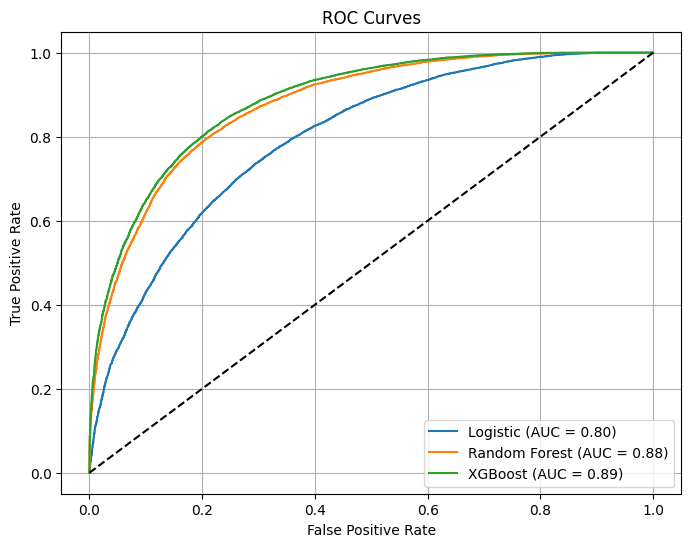

In [11]:
plt.figure(figsize=(8, 6))
for name, model in {
    "Logistic": log_best,
    "Random Forest": rf_best,
    "XGBoost": xgb_best
}.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid(True)
plt.show()


### Model Comparision and Final Selection

Based on the above evaluation obviously Logistic is our worst performing model but that was to be expected, for this problem it served more of a sanity check and confirmation of heading in the right direction. Random forest and XGBoost had similar performance but due to speed and slightly better results we will be moving forward and selecting XGBoost as our final model for this project.

### Final Predictor 

I put together the below code as a framework for future testing and ease of showcasing the model on new flights and samples of never seen before flights. My final deliverable that I wanted to achieve was a model that could provide a confidence interval on likelyhood of delay occuring for a given Airline, Airport, and month. This was the framwork I followed below to create a class to take the 3 user inputs and perform model evaluation. 

In [ ]:
from datetime import datetime
import pandas as pd

class DelayPredictor:
    def __init__(self, model, df_reference):
        self.model = model
        self.df = df_reference.copy()
        self.feature_cols = model.feature_names_in_

        # Lookup tables for engineered features
        self.carrier_rate = self.df.groupby('carrier')['carrier_delay_rate_overall'].mean()
        self.airport_rate = self.df.groupby('airport')['airport_delay_rate'].mean()
        self.month_rate = self.df.groupby('month')['month_delay_rate'].mean()
        self.carrier_airport_rate = self.df.groupby(['carrier', 'airport'])['carrier_airport_delay_rate'].mean()
        self.carrier_airport_volume = self.df.groupby(['carrier', 'airport'])['carrier_airport_volume'].mean()
        self.airport_month_volume = self.df.groupby(['airport', 'month'])['airport_month_volume'].mean()

        self.means = self.df[self.feature_cols].mean()

    def _build_feature_row(self, carrier, airport, month):

        # Check for missing keys before prediction
        missing_keys = []
        if carrier not in self.carrier_rate: missing_keys.append("carrier")
        if airport not in self.airport_rate: missing_keys.append("airport")
        if month not in self.month_rate: missing_keys.append("month")
        if (carrier, airport) not in self.carrier_airport_rate: missing_keys.append("carrier-airport pair")
        if (carrier, airport) not in self.carrier_airport_volume: missing_keys.append("carrier-airport volume")
        if (airport, month) not in self.airport_month_volume: missing_keys.append("airport-month volume")

        if missing_keys:
            raise ValueError(f"Cannot predict — missing historical data for: {', '.join(missing_keys)}")

        # Build feature row from lookups
        row = {
            'carrier_delay_rate_overall': self.carrier_rate[carrier],
            'airport_delay_rate': self.airport_rate[airport],
            'month_delay_rate': self.month_rate[month],
            'carrier_airport_delay_rate': self.carrier_airport_rate[(carrier, airport)],
            'carrier_airport_volume': self.carrier_airport_volume[(carrier, airport)],
            'airport_month_volume': self.airport_month_volume[(airport, month)],
            'month': month,
        }

        # Fill in remaining required features with dataset mean
        for col in self.feature_cols:
            if col not in row:
                row[col] = self.means[col]

        return pd.DataFrame([row])[self.feature_cols]

    def predict_delay_confidence(self, carrier, airport, month, debug=False):
        input_df = self._build_feature_row(carrier, airport, month)
        
        if debug:
            print("===== Feature Row Used for Prediction =====")
            display(input_df.T.sort_index())

        prob = self.model.predict_proba(input_df)[0][1]
        return round(prob * 100, 2)
    




Testing with a flight from Delta leaving LAX during september my birth month. 

In [20]:
predictor = DelayPredictor(xgb_best, df)

try:
    confidence = predictor.predict_delay_confidence('DL', 'LAX', 9, debug=True)
    print(f"Predicted Delay Confidence: {confidence}%")
except ValueError as e:
    print(str(e))


===== Feature Row Used for Prediction =====


,0
airport_delay_rate,9.687787e-01
airport_month_volume,2.448222e+00
arr_diverted,-4.559384e-18
arr_flights,5.338625e-17
carrier_airport_delay_rate,-2.160484e-01
carrier_airport_volume,2.341903e+00
carrier_ct_rate,-3.697246e-17
carrier_delay_pct,-2.574809e-16
carrier_delay_rate,8.090835e-17
carrier_delay_rate_overall,-1.755500e+00


Predicted Delay Confidence: 43.25%


### Sample of new flights to test models performance

In [ ]:
sample_flights = pd.DataFrame([
    {'carrier': 'AA', 'airport': 'ORD', 'month': 1},
    {'carrier': 'DL', 'airport': 'ATL', 'month': 7},
    {'carrier': 'UA', 'airport': 'DEN', 'month': 12},
    {'carrier': 'AS', 'airport': 'SEA', 'month': 4},
    {'carrier': 'WN', 'airport': 'PHX', 'month': 8},
    {'carrier': 'B6', 'airport': 'JFK', 'month': 11},
    {'carrier': 'NK', 'airport': 'MCO', 'month': 3},
    {'carrier': 'HA', 'airport': 'HNL', 'month': 5},   
    {'carrier': 'AS', 'airport': 'PDX', 'month': 10},
    {'carrier': 'AA', 'airport': 'DFW', 'month': 2}, 
    {'carrier': 'WN', 'airport': 'OAK', 'month': 4}, 
    {'carrier': 'DL', 'airport': 'SLC', 'month': 6},
])


In [22]:
def batch_predict_confidence(predictor, flight_df, debug=False):
    results = []

    for idx, row in flight_df.iterrows():
        try:
            confidence = predictor.predict_delay_confidence(
                row['carrier'], row['airport'], row['month'], debug=debug
            )
            results.append({
                'carrier': row['carrier'],
                'airport': row['airport'],
                'month': row['month'],
                'confidence': confidence
            })
        except ValueError as e:
            results.append({
                'carrier': row['carrier'],
                'airport': row['airport'],
                'month': row['month'],
                'confidence': None,
                'error': str(e)
            })

    return pd.DataFrame(results)

In [23]:
results = batch_predict_confidence(predictor, sample_flights)
display(results)


,carrier,airport,month,confidence
0,AA,ORD,1,88.589996
1,DL,ATL,7,64.779999
2,UA,DEN,12,77.620003
3,AS,SEA,4,57.430000
4,WN,PHX,8,95.050003
5,B6,JFK,11,91.720001
6,NK,MCO,3,86.120003
7,HA,HNL,5,28.280001
8,AS,PDX,10,16.020000
9,AA,DFW,2,89.370003


Wide Range of delay chances, anything below 45% I would consider low risk of delay, with anything above 90% being High, my model tends to lean towards higher chance of delay rather than not based on how I created the features and fed them into the model. 

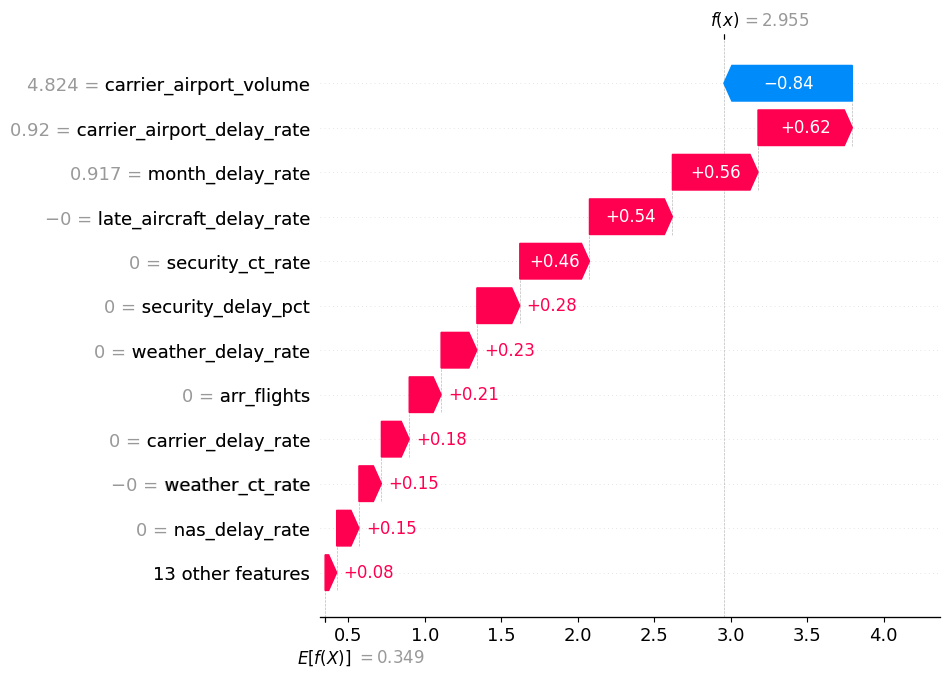

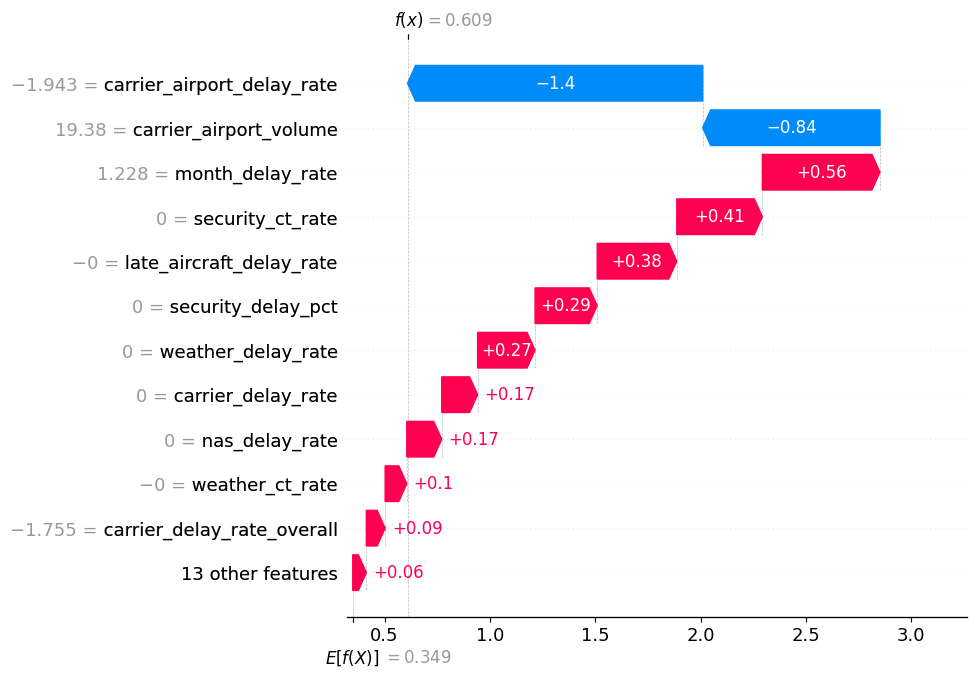

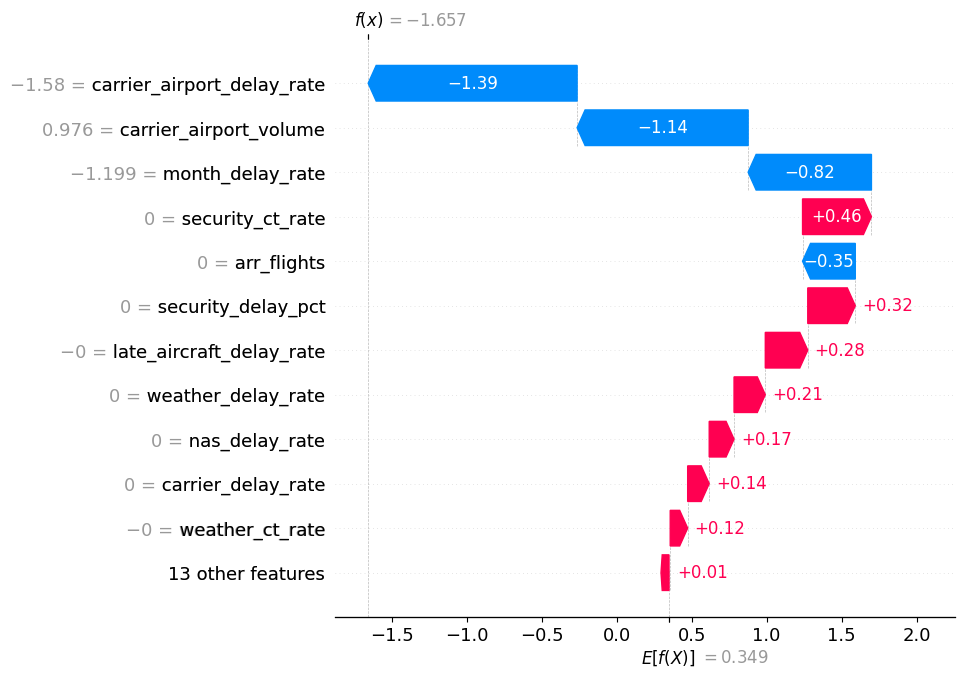

In [24]:
import shap

explainer = shap.Explainer(xgb_best)

# High confidence prediction (e.g. WN → PHX, Aug: 95%)
high = predictor._build_feature_row('WN', 'PHX', 8)

# Medium confidence prediction (e.g. DL → ATL, Jul: 64%)
med = predictor._build_feature_row('DL', 'ATL', 7)

# Low confidence prediction (e.g. AS → PDX, Oct: 16%)
low = predictor._build_feature_row('AS', 'PDX', 10)

shap_values_high = explainer(high)
shap_values_med = explainer(med)
shap_values_low = explainer(low)

# Waterfall plots
shap.plots.waterfall(shap_values_high[0], max_display=12)
shap.plots.waterfall(shap_values_med[0], max_display=12)
shap.plots.waterfall(shap_values_low[0], max_display=12)

Big Takeaway of the above figures is to highlight what the most important features are in generating the delay confidence interval, you can see accross the board the heaviest hitters are carrier airport delay rate and carrier airport voloume which are very specific to ariport and carrier so you would expect those to hold the most weight. The wide variety and abiltiy to draw different trends based on airports gives me confidence in my models predictions. 

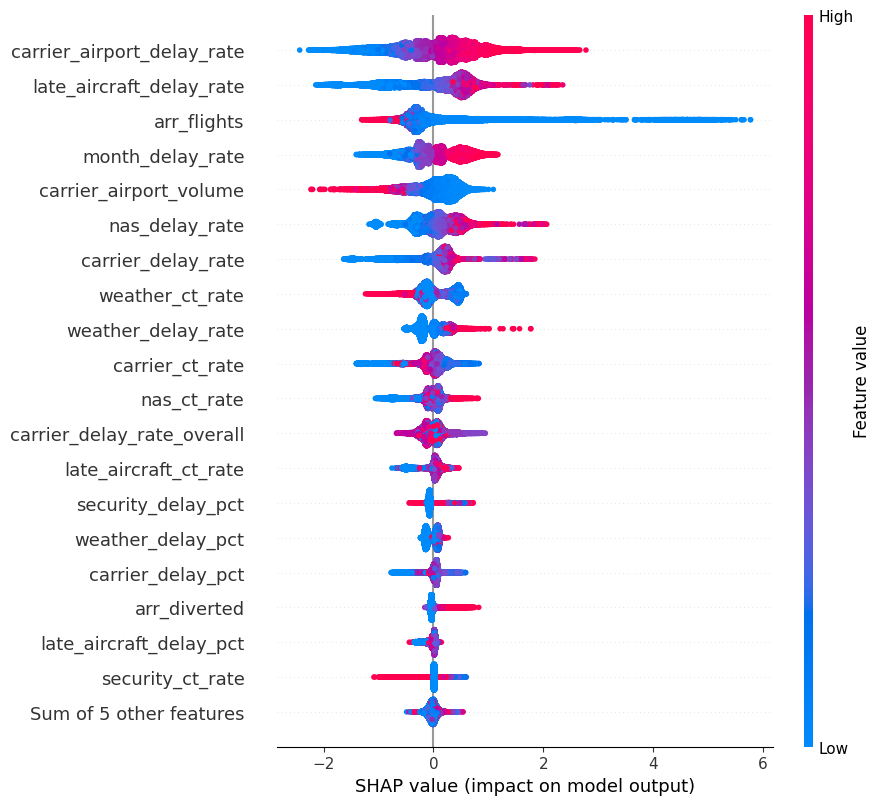

In [25]:
# Compute SHAP values for full test set
shap_values_test = explainer(X_test)

# Summary plot: feature importance across the dataset
shap.plots.beeswarm(shap_values_test, max_display=20)


### Final Thoughts and Future goals:

Big take aways with this model is the performance is acceptable, I would have liked to get some more unique to airport trends or some more granular data instead of monthly totals, main reason being I am missing some of the holiday trends or unique events during the year. There would have been a much greater task of preprocessing and wrangling the data but I think it would be interesting to see. 

I would have liked to also tie in real time weather as part of the estimate, if you were expecting to take a flight this upcoming December and we're expected to have large snow storms I would like to weigh that factor higher. 

There were some other things that I feel could have made the model stronger with some more engineerd features but I am happy with the current performance and may come back to improve on this later. 

Final goal would have been to wrap the whole thing up into a nice little application or dashboard that could have the user select from upcoming flights and or drop down menues to easily see what their chances of an ontime flight will be. 